<a href="https://colab.research.google.com/github/pcmouadji-dot/deep_learning/blob/main/Facial_Keypoints_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

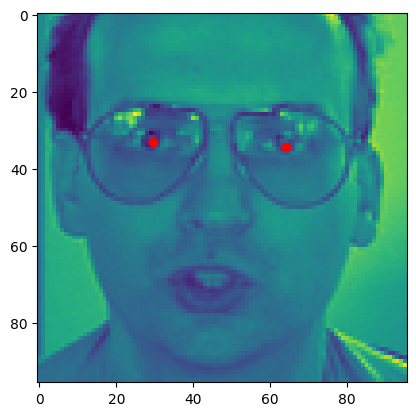

In [23]:
train_df=pd.read_csv('training.csv')
test_df=pd.read_csv('test.csv')
i=6
def show_image(image_string):
  pixels=image_string.split(' ')
  pixels=np.array(pixels,dtype='uint8')
  img=pixels.reshape(96,96)
  plt.imshow(img)
  plt.scatter(train_df.loc[i,'left_eye_center_x'],train_df.loc[i,'left_eye_center_y'],c='r')
  plt.scatter(train_df.loc[i,'right_eye_center_x'],train_df.loc[i,'right_eye_center_y'],c='r')
  plt.show()
show_image(train_df.loc[i,'Image'])

In [21]:
train_df = pd.read_csv('training.csv')
train_df = train_df.dropna()   # <-- do this BEFORE building X and y

def to_image(pixel_string):
    return np.array(pixel_string.split(' '), dtype=np.float32).reshape(96, 96, 1) / 255.0

X = np.stack(train_df['Image'].apply(to_image).values)

target_cols = [c for c in train_df.columns if c != 'Image']
y = train_df[target_cols].values.astype(np.float32)
y = (y - 48) / 48  # normalize to roughly [-1, 1]

print("NaNs in X:", np.isnan(X).sum())  # should be 0
print("NaNs in y:", np.isnan(y).sum())  # should be 0

NaNs in X: 0
NaNs in y: 0


In [24]:
model = tf.keras.Sequential(
    [
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(96, 96, 1)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(2, 2),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D(2, 2),
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D(2, 2),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(512, activation='relu'),
        tf.keras.layers.Dense(30)
    ]
)

def rmse(y_true, y_pred):
    return tf.sqrt(tf.reduce_mean(tf.square(y_pred - y_true)))

model.compile(optimizer='adam', loss='mse', metrics=[rmse])  # <- loss='mse', not the rmse function

callback = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-6)
]

model.fit(X, y, callbacks=callback, batch_size=64, validation_split=0.1, epochs=200)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 8s 149ms/step - loss: 0.5596 - rmse: 0.4278 - val_loss: 0.1161 - val_rmse: 0.3426 - learning_rate: 0.0010
Epoch 2/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0142 - rmse: 0.1184 - val_loss: 0.1054 - val_rmse: 0.3263 - learning_rate: 0.0010
Epoch 3/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0066 - rmse: 0.0810 - val_loss: 0.0921 - val_rmse: 0.3050 - learning_rate: 0.0010
Epoch 4/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0049 - rmse: 0.0701 - val_loss: 0.0874 - val_rmse: 0.2971 - learning_rate: 0.0010
Epoch 5/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0043 - rmse: 0.0657 - val_loss: 0.0802 - val_rmse: 0.2845 - learning_rate: 0.0010
Epoch 6/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0041 - rmse: 0.0638 - val_loss: 0.0721 - val_rmse: 0.2698 - learning_rate: 0.0010
Epoch 7/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0041 - rmse: 0.0636 - val_loss: 0.0669 - val_rmse: 0.2600 - learning_rate

In [25]:
model.fit(X,y,callbacks=callback,batch_size=64,validation_split=0.1,epochs=200)


Epoch 1/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 6.9345e-04 - rmse: 0.0262 - val_loss: 0.0031 - val_rmse: 0.0534 - learning_rate: 7.8125e-06
Epoch 2/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 6.9924e-04 - rmse: 0.0270 - val_loss: 0.0031 - val_rmse: 0.0534 - learning_rate: 7.8125e-06
Epoch 3/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 7.0042e-04 - rmse: 0.0264 - val_loss: 0.0031 - val_rmse: 0.0534 - learning_rate: 7.8125e-06
Epoch 4/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 6.9784e-04 - rmse: 0.0263 - val_loss: 0.0031 - val_rmse: 0.0534 - learning_rate: 7.8125e-06
Epoch 5/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 6.9800e-04 - rmse: 0.0262 - val_loss: 0.0031 - val_rmse: 0.0534 - learning_rate: 7.8125e-06
Epoch 6/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 6.9654e-04 - rmse: 0.0267 - val_loss: 0.0031 - val_rmse: 0.0534 - learning_rate: 3.9063e-06
Epoch 7/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 6.9746e-04 - rmse: 0.0263 - 

In [26]:
test_df = pd.read_csv('test.csv')
X_test = np.stack(test_df['Image'].apply(to_image).values)
preds = model.predict(X_test)
preds = preds * 48 + 48
preds = np.clip(preds, 0, 96)

target_cols = [c for c in train_df.columns if c != 'Image']
pred_df = pd.DataFrame(preds, columns=target_cols)
pred_df['ImageId'] = test_df['ImageId'].values

lookup_df = pd.read_csv('IdLookupTable.csv')

def get_prediction(row):
    image_id = row['ImageId']
    feature_name = row['FeatureName']
    return pred_df.loc[pred_df['ImageId'] == image_id, feature_name].values[0]

lookup_df['Location'] = lookup_df.apply(get_prediction, axis=1)

submission = lookup_df[['RowId', 'Location']]
submission.to_csv('submission.csv', index=False)

print(submission.head())

56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
   RowId   Location
0      1  66.171127
1      2  36.542767
2      3  28.950634
3      4  35.995316
4      5  58.954258


In [27]:
lookup_features = set(lookup_df['FeatureName'].unique())
pred_columns = set(pred_df.columns) - {'ImageId'}

print("In lookup but not in pred_df:", lookup_features - pred_columns)
print("In pred_df but not in lookup:", pred_columns - lookup_features)

In lookup but not in pred_df: set()
In pred_df but not in lookup: set()
